# 02 — EDA & Visualisation
**Aviation Safety Risk Prediction — NTSB + NOAA Dataset**

This notebook is inserted **between** NB01 (data preparation) and NB03 (feature engineering).  
It provides a comprehensive view of the clean dataset before any feature transformation.

### Contents
1. Dataset overview & data types
2. Target variable — univariate
3. Numeric features — univariate distributions
4. Categorical features — univariate bar plots
5. Correlation analysis — heatmap & ranked correlations
6. Bivariate: each key feature vs target severity
7. Multivariate: weather risk composite × flight conditions × severity
8. Temporal trends
9. Geographic distribution (state-level)
10. Key findings summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

OUTPUT_DIR = 'outputs/eda'
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv('../data/processed/ntsb_clean_final.csv', low_memory=False)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df['ev_highest_injury'].value_counts())


Loaded: 28,810 rows × 109 columns

Target distribution:
ev_highest_injury
NONE    16075
FATL     4810
MINR     4206
SERS     3719
Name: count, dtype: int64


## 1. Dataset Overview

In [2]:
# Data types summary
dtype_summary = df.dtypes.value_counts()
print("Data types:")
print(dtype_summary)

print(f"\nMissing values total: {df.isnull().sum().sum()}")

# First 5 rows
df.head(3)


Data types:
object     46
float64    43
int64      12
bool        8
Name: count, dtype: int64

Missing values total: 12


,ev_dow,ev_time,ev_state,ev_year,ev_month,latlong_acq,ev_nr_apt_loc,apt_dir,wx_src_iic,wx_obs_time,wx_obs_dir,light_cond,sky_cond_nonceil,sky_cond_ceil,wx_temp_c,wx_dew_pt_c,wind_dir_deg,wind_dir_ind,wind_vel_kts,wind_vel_ind,gust_ind,gust_kts,ev_highest_injury,wx_cond_basic,dec_latitude,dec_longitude,Aircraft_Key,far_part,flt_plan_filed,flight_plan_activated,...,noaa_rain,noaa_snow,noaa_thunder,noaa_temp_c,noaa_temp_max_c,noaa_temp_min_c,is_missing_rwy_len,is_missing_rwy_width,is_missing_pax_seats,is_missing_crew_age,is_missing_fuel_on_board,is_missing_afm_hrs,is_missing_afm_hrs_last_insp,is_missing_acft_year,is_missing_wind_vel_kts,ev_season,apt_elev_m,wx_obs_elev_m,sky_ceil_ht_m,sky_nonceil_ht_m,rwy_len_m,rwy_width_m,vis_km,noaa_visib_km,apt_dist_km,wx_obs_dist_km,cert_max_gr_wt_kg,fuel_on_board_l,altimeter_hpa,noaa_prcp_mm
0,Tu,2230.0,CA,2008,1,MEAS,ONAP,150.0,WFAC,2254.0,220.0,DAYL,CLER,NONE,13.888889,0.0,80.0,U,10.0,F,T,0.0,NONE,VMC,38.223888,-122.449722,1,091,NONE,N,...,False,False,False,8.166667,13.000000,4.000000,0,0,1,0,1,0,0,1,0,winter,3.0,0.6,0.0,0.0,823.0,13.7,16.093,15.932,0.0,11.265,1088.6,170.3,1022.35,0.0
1,Tu,2230.0,CA,2008,1,MEAS,ONAP,150.0,WFAC,2254.0,220.0,DAYL,CLER,NONE,13.888889,0.0,80.0,U,10.0,F,T,0.0,NONE,VMC,38.223888,-122.449722,2,091,NONE,N,...,False,False,False,8.166667,13.000000,4.000000,0,0,1,0,1,0,1,1,0,winter,3.0,0.6,0.0,0.0,823.0,13.7,16.093,15.932,0.0,11.265,889.0,170.3,1022.35,0.0
2,Tu,2200.0,TX,2008,1,MEAS,ONAP,150.0,WFAC,1553.0,0.0,DAYL,CLER,NONE,12.777778,-10.0,360.0,U,15.0,F,F,20.0,NONE,VMC,29.506111,-95.476669,1,091,NONE,N,...,False,False,False,10.944444,18.888889,6.111111,0,0,1,0,1,0,1,1,0,winter,20.7,188.7,0.0,0.0,1524.9,30.5,16.093,16.093,0.0,0.000,1292.7,170.3,1036.91,0.0


In [3]:
# Quick descriptive statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
df[numeric_cols].describe().T.round(2).head(20)


Numeric columns: 55


,count,mean,std,min,25%,50%,75%,max
ev_time,28810.0,1587.00,648.93,0.00,1430.00,1743.00,2030.00,2359.00
ev_year,28810.0,2016.22,5.12,2008.00,2012.00,2016.00,2021.00,2025.00
ev_month,28810.0,6.60,3.02,1.00,4.00,7.00,9.00,12.00
apt_dir,28810.0,152.33,75.65,0.00,150.00,150.00,150.00,360.00
wx_obs_time,28810.0,1539.49,542.31,0.00,1335.00,1600.00,1935.00,2359.00
wx_obs_dir,28810.0,132.85,122.06,0.00,0.00,114.00,240.00,360.00
wx_temp_c,28810.0,17.59,12.83,-57.22,12.22,21.11,27.22,50.00
wx_dew_pt_c,28810.0,6.32,12.15,-38.89,-1.11,7.78,16.11,37.78
wind_dir_deg,28810.0,145.49,119.02,0.00,0.00,150.00,250.00,360.00
wind_vel_kts,28810.0,7.69,3.83,0.00,5.00,7.00,9.00,75.00


## 2. Target Variable — Univariate

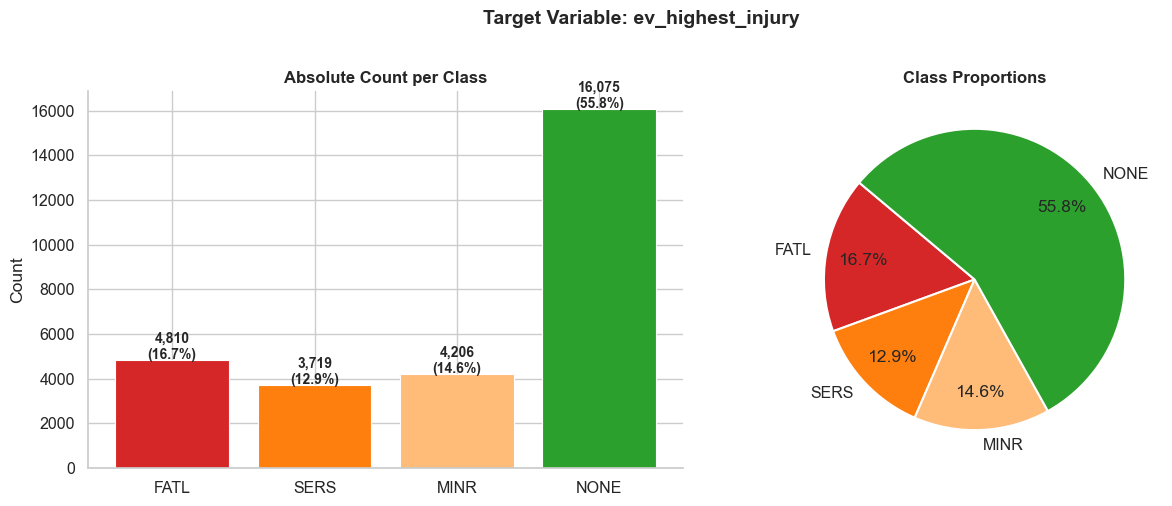


Class imbalance ratio NONE/FATL: 3.34x
Minority class (FATL) share: 16.7%


In [4]:
injury_order = ['FATL', 'SERS', 'MINR', 'NONE']
colors       = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c']
vc = df['ev_highest_injury'].value_counts()[injury_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(injury_order, vc.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 60, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Absolute Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
sns.despine(ax=axes[0])

# Pie chart
axes[1].pie(vc.values, labels=injury_order, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Proportions', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: ev_highest_injury', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio NONE/FATL: {vc['NONE']/vc['FATL']:.2f}x")
print(f"Minority class (FATL) share: {vc['FATL']/len(df)*100:.1f}%")


## 3. Numeric Features — Univariate Distributions

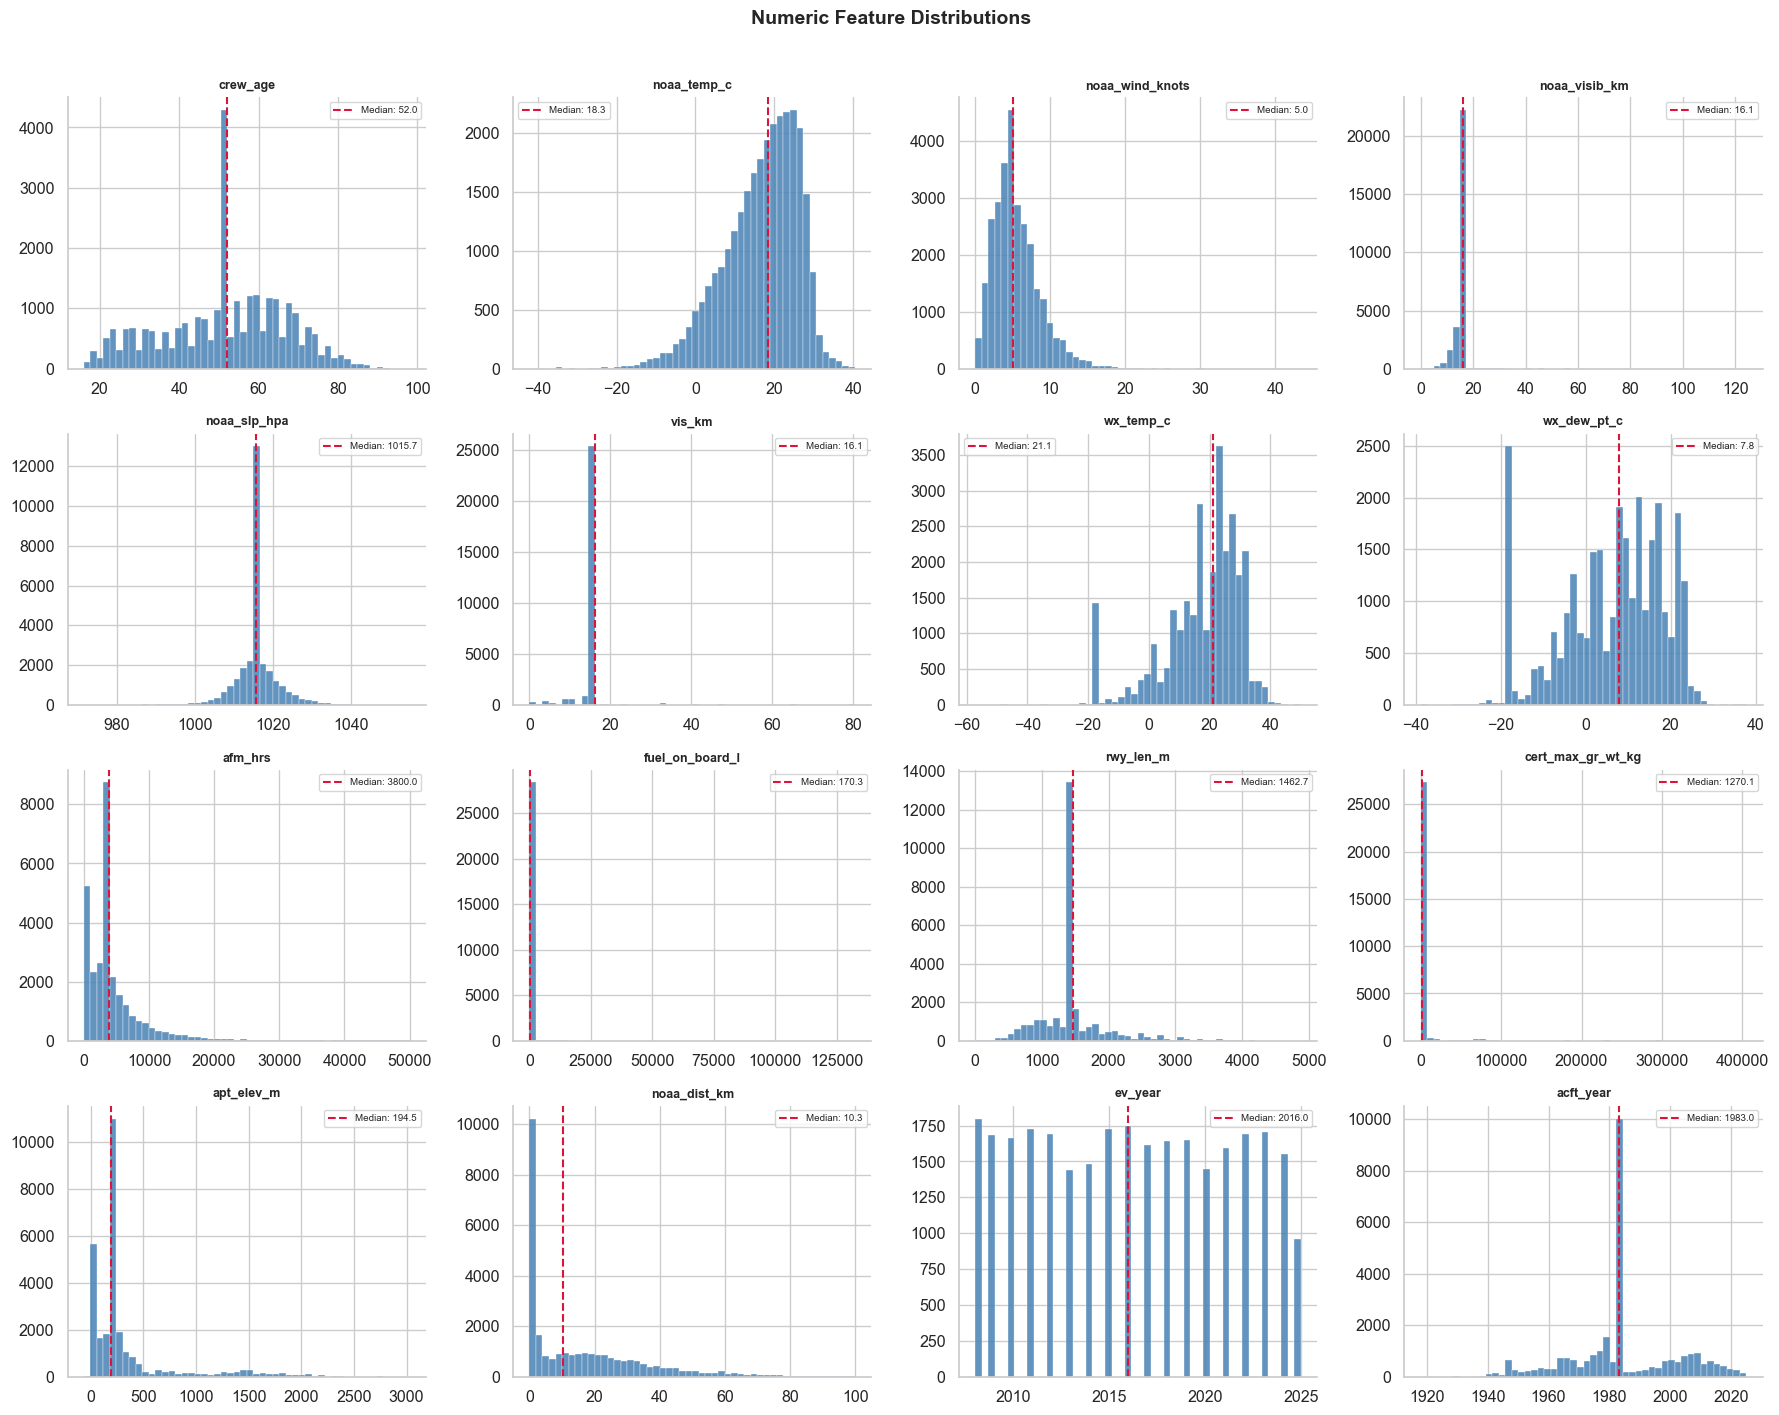

In [5]:
# Select key numeric features for distribution plots
key_numeric = [
    'crew_age', 'noaa_temp_c', 'noaa_wind_knots', 'noaa_visib_km',
    'noaa_slp_hpa', 'vis_km', 'wx_temp_c', 'wx_dew_pt_c',
    'afm_hrs', 'fuel_on_board_l', 'rwy_len_m', 'cert_max_gr_wt_kg',
    'apt_elev_m', 'noaa_dist_km', 'ev_year', 'acft_year',
]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_numeric[:16]):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(data.median(), color='crimson', linewidth=1.5, linestyle='--', label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

for i in range(len(key_numeric), 16):
    axes[i].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Skewness table
skew_df = df[key_numeric].skew().abs().sort_values(ascending=False).reset_index()
skew_df.columns = ['feature', 'abs_skewness']
skew_df['needs_log_transform'] = skew_df['abs_skewness'] > 1.0
print("Skewness summary (|skew| > 1 → consider log transform):")
print(skew_df.to_string(index=False))


Skewness summary (|skew| > 1 → consider log transform):
          feature  abs_skewness  needs_log_transform
  fuel_on_board_l     20.274946                 True
cert_max_gr_wt_kg      9.288860                 True
    noaa_visib_km      8.884027                 True
           vis_km      6.603788                 True
          afm_hrs      3.640733                 True
       apt_elev_m      2.507925                 True
     noaa_dist_km      1.402557                 True
  noaa_wind_knots      1.371033                 True
        rwy_len_m      1.365141                 True
        wx_temp_c      1.198490                 True
      noaa_temp_c      0.831817                False
      wx_dew_pt_c      0.547364                False
     noaa_slp_hpa      0.353296                False
         crew_age      0.225150                False
          ev_year      0.019354                False
        acft_year      0.014226                False


## 4. Categorical Features — Univariate Bar Plots

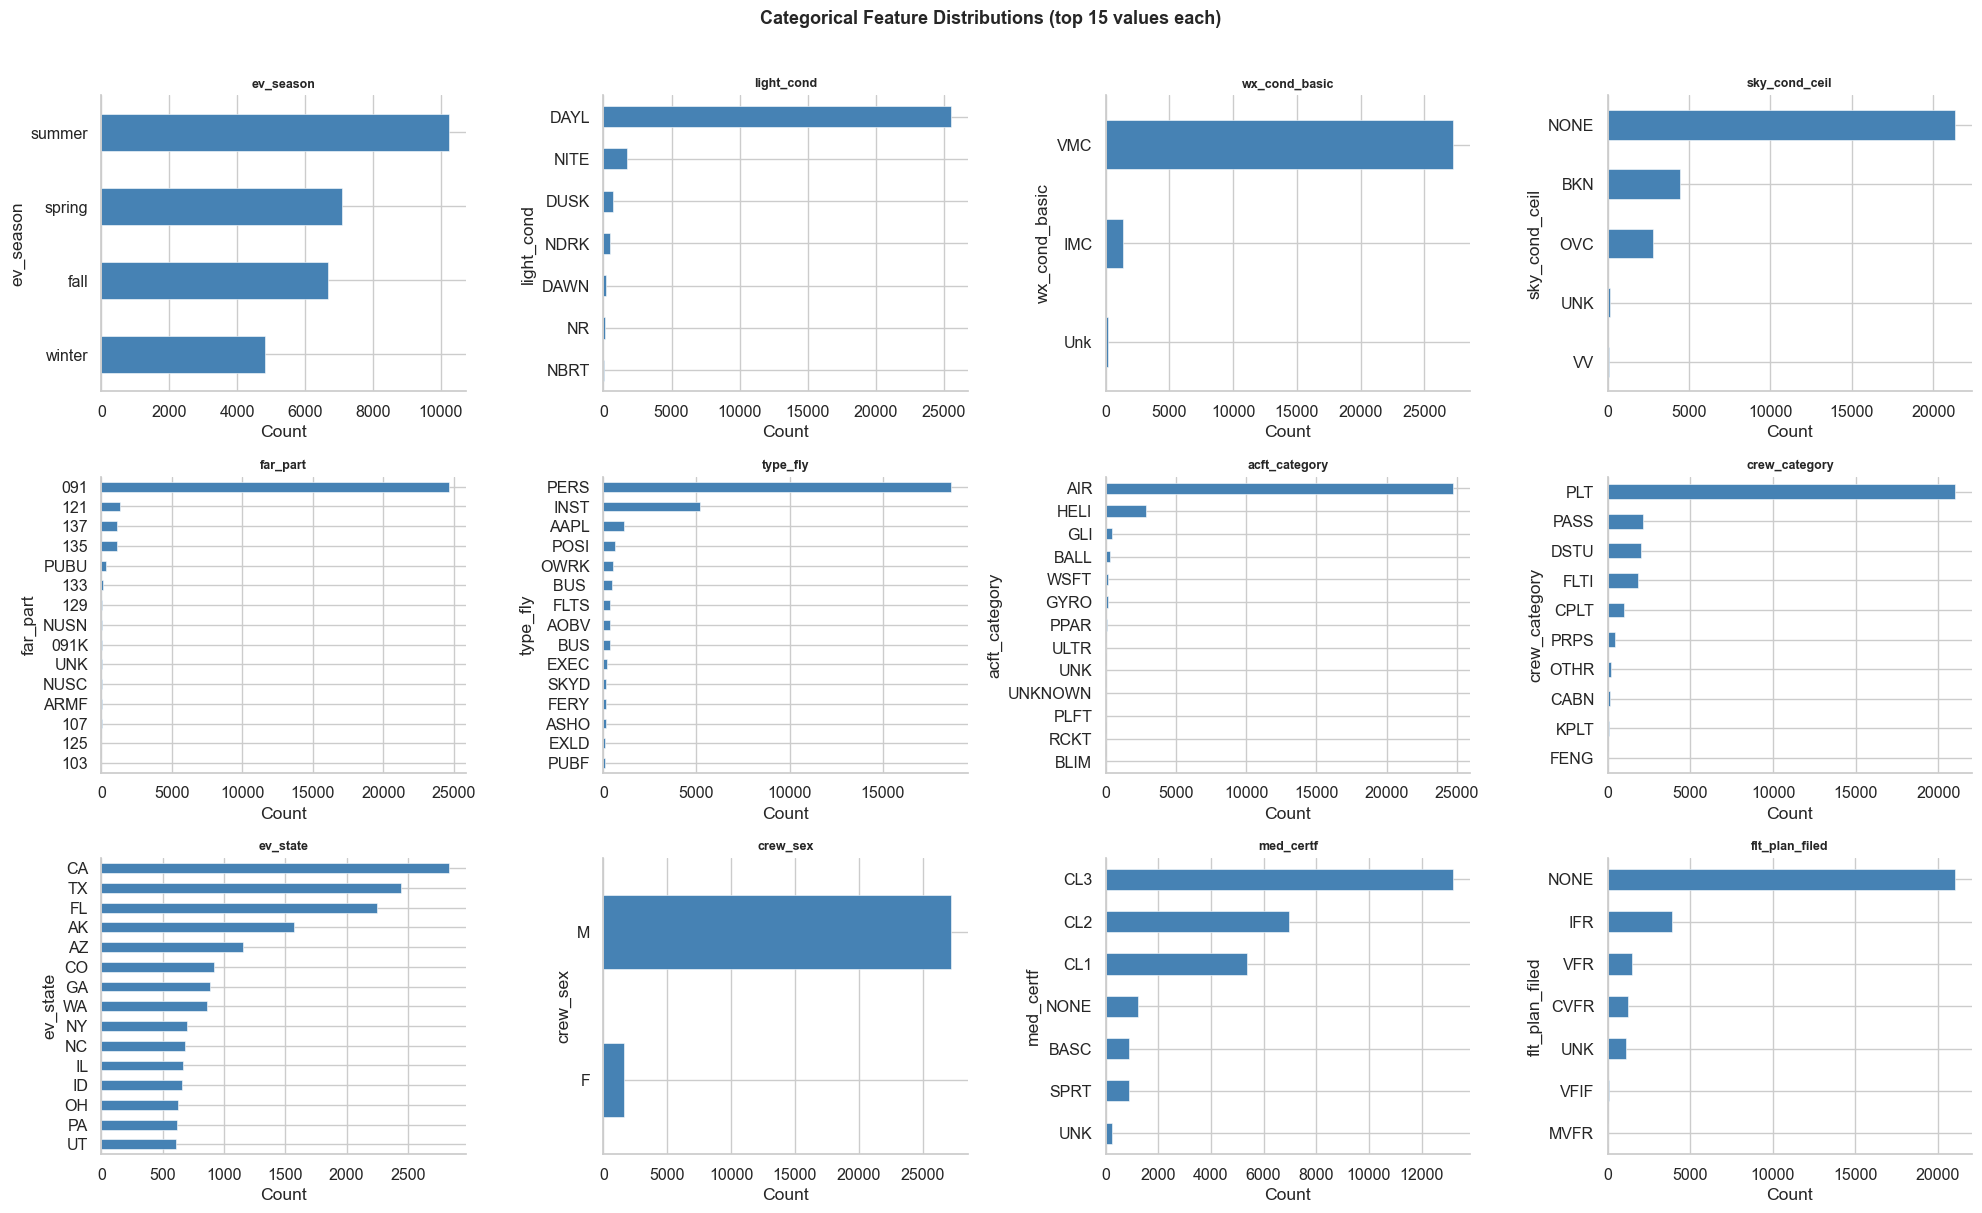

In [7]:
key_cat = [
    'ev_season', 'light_cond', 'wx_cond_basic', 'sky_cond_ceil',
    'far_part', 'type_fly', 'acft_category', 'crew_category',
    'ev_state', 'crew_sex', 'med_certf', 'flt_plan_filed',
]
key_cat = [c for c in key_cat if c in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(key_cat[:12]):
    ax = axes[i]
    vc_col = df[col].value_counts().head(15)
    vc_col.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    sns.despine(ax=ax)

for i in range(len(key_cat), 12):
    axes[i].set_visible(False)

plt.suptitle('Categorical Feature Distributions (top 15 values each)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Correlation Analysis

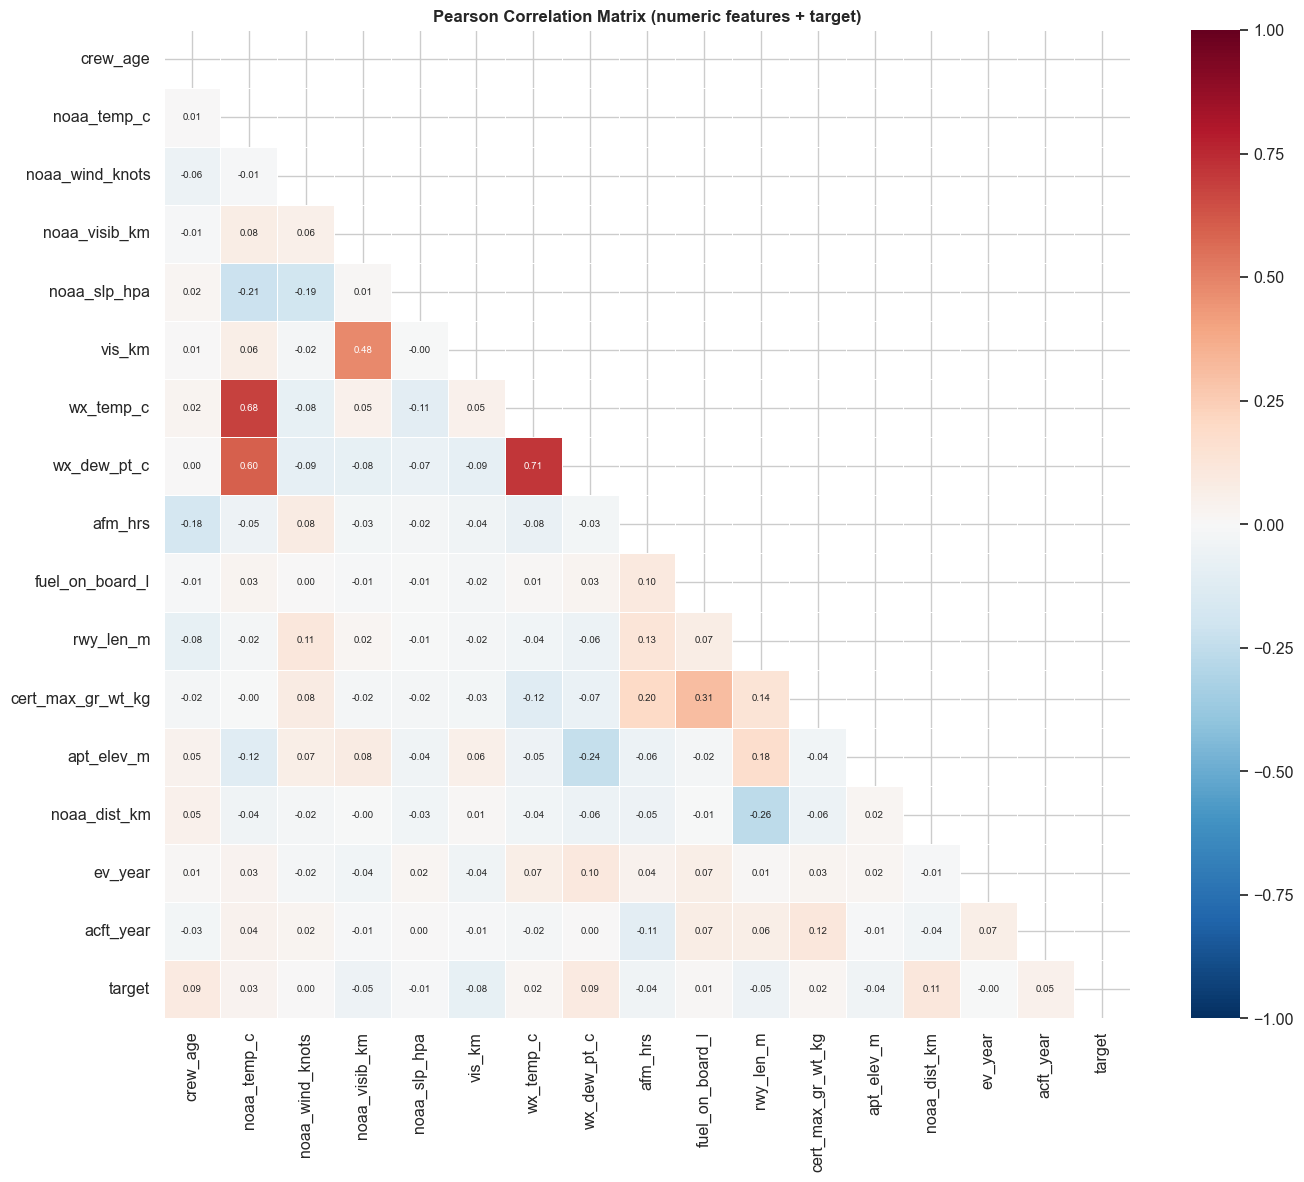

In [8]:
# Encode target for correlation
target_encoded = df['ev_highest_injury'].map({'NONE':0,'MINR':1,'SERS':2,'FATL':3})
corr_df = df[key_numeric].copy()
corr_df['target'] = target_encoded

corr_matrix = corr_df.corr()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, square=False, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation Matrix (numeric features + target)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Top 20 correlations with target (|Pearson r|):
noaa_dist_km         0.1108
crew_age             0.0896
wx_dew_pt_c          0.0861
vis_km               0.0839
noaa_visib_km        0.0546
acft_year            0.0542
rwy_len_m            0.0470
apt_elev_m           0.0399
afm_hrs              0.0393
noaa_temp_c          0.0326
wx_temp_c            0.0211
cert_max_gr_wt_kg    0.0184
fuel_on_board_l      0.0122
noaa_slp_hpa         0.0087
ev_year              0.0030
noaa_wind_knots      0.0023
Name: target, dtype: float64


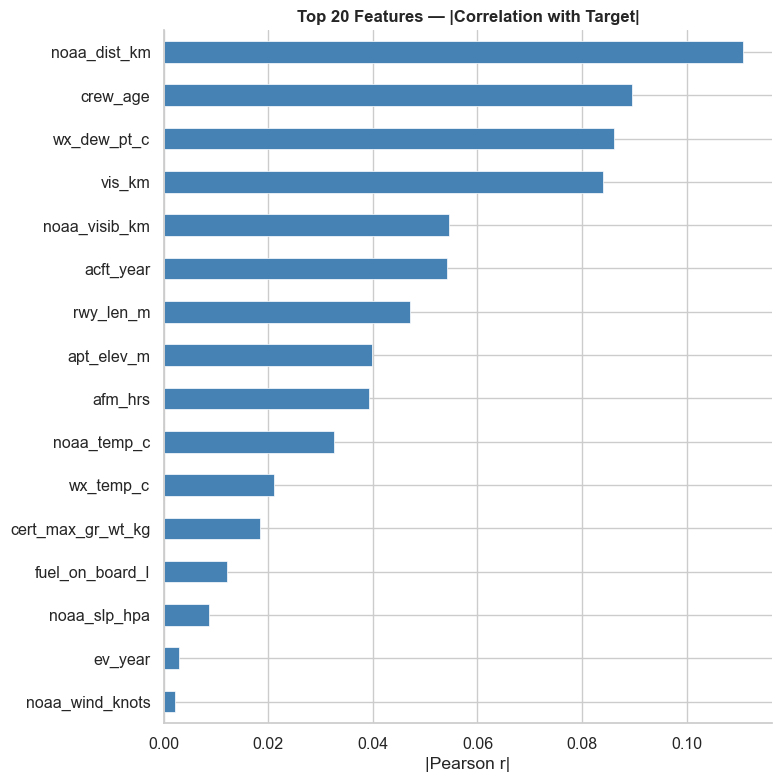

In [9]:
# Top correlations with target
target_corr = corr_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("Top 20 correlations with target (|Pearson r|):")
print(target_corr.head(20).round(4))

fig, ax = plt.subplots(figsize=(8, 8))
target_corr.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue',
                                         edgecolor='white', linewidth=0.5)
ax.set_title('Top 20 Features — |Correlation with Target|', fontsize=12, fontweight='bold')
ax.set_xlabel('|Pearson r|')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bivariate Analysis — Key Features vs Target

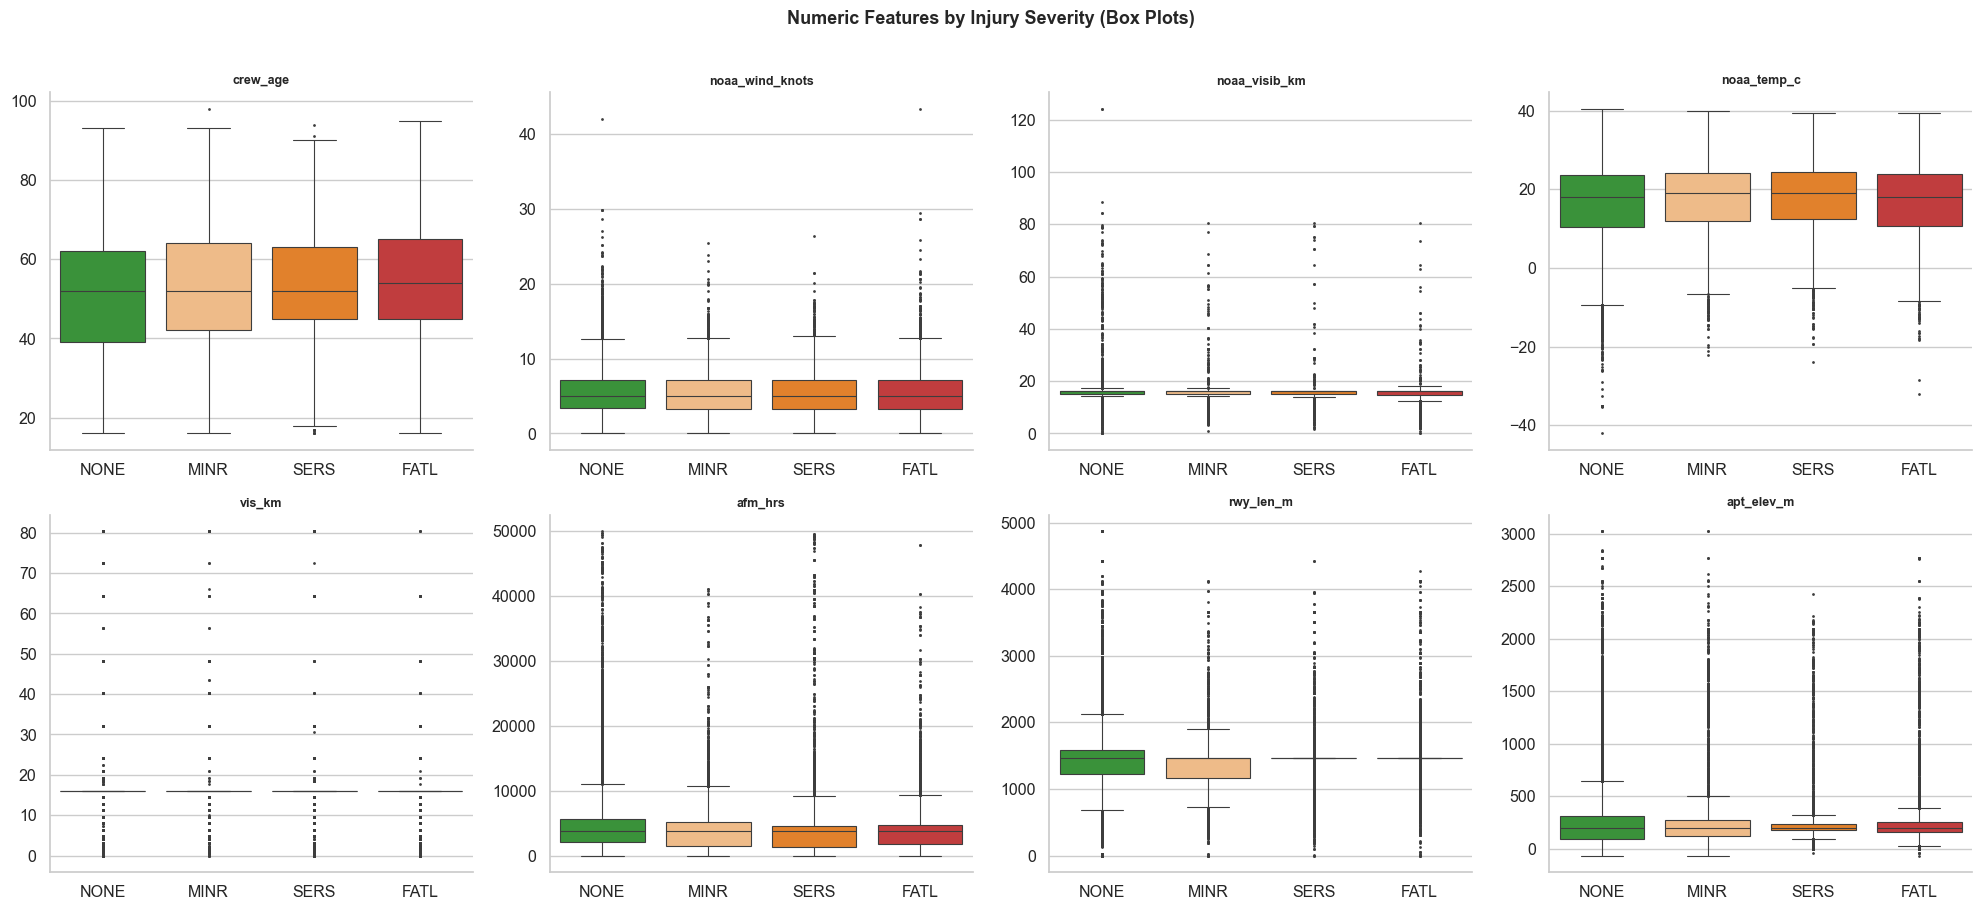

In [10]:
# Box plots: numeric features by injury severity
bivariate_num = [
    'crew_age', 'noaa_wind_knots', 'noaa_visib_km',
    'noaa_temp_c', 'vis_km', 'afm_hrs', 'rwy_len_m', 'apt_elev_m'
]
bivariate_num = [c for c in bivariate_num if c in df.columns]
order = ['NONE', 'MINR', 'SERS', 'FATL']
palette = {'NONE':'#2ca02c','MINR':'#ffbb78','SERS':'#ff7f0e','FATL':'#d62728'}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(bivariate_num[:8]):
    ax = axes[i]
    sns.boxplot(data=df, x='ev_highest_injury', y=col, order=order, palette=palette,
                fliersize=1, linewidth=0.8, ax=ax)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    sns.despine(ax=ax)

plt.suptitle('Numeric Features by Injury Severity (Box Plots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_bivariate_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


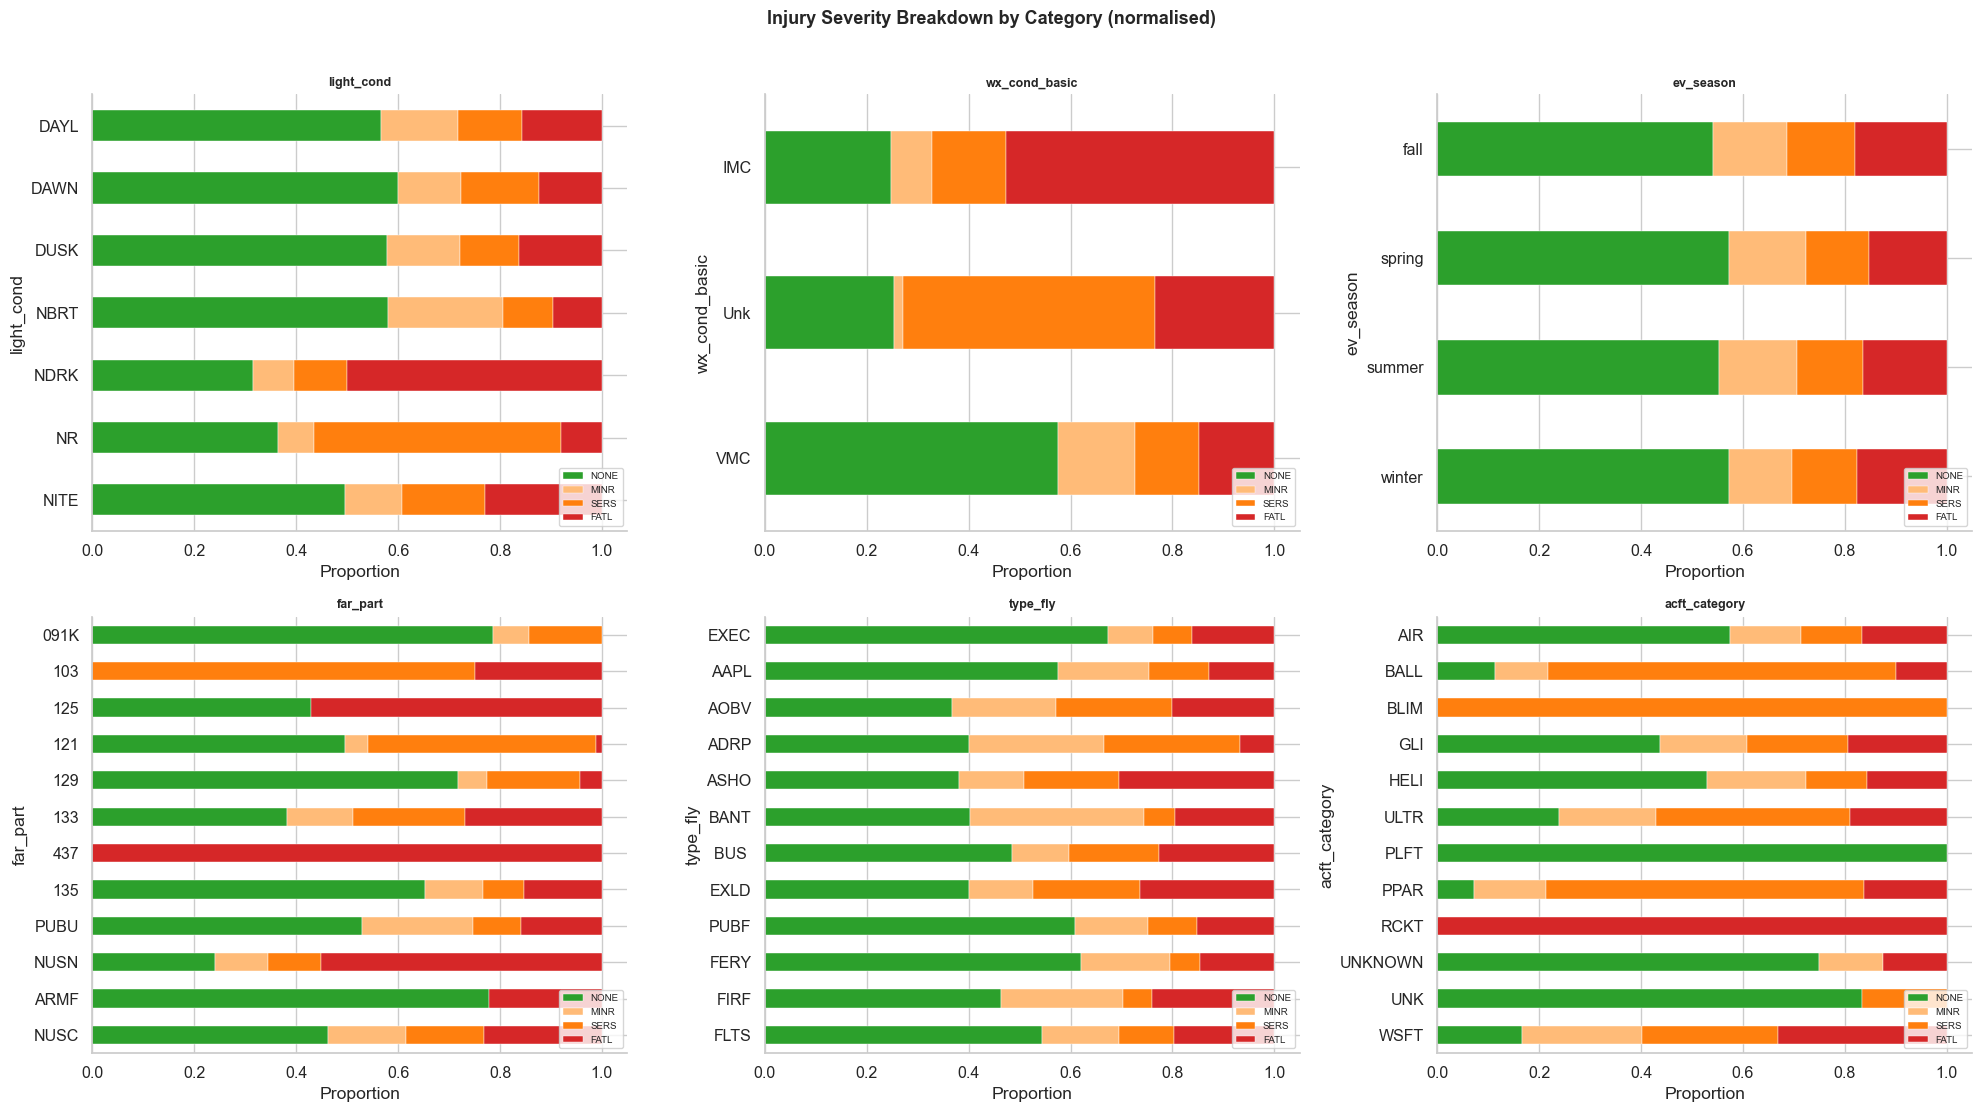

In [11]:
# Stacked bar plots: categorical features vs target
bivariate_cat = ['light_cond', 'wx_cond_basic', 'ev_season', 'far_part', 'type_fly', 'acft_category']
bivariate_cat = [c for c in bivariate_cat if c in df.columns]
colors_stack = ['#2ca02c', '#ffbb78', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, col in enumerate(bivariate_cat[:6]):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['ev_highest_injury'], normalize='index')[
        [c for c in ['NONE','MINR','SERS','FATL'] if c in df['ev_highest_injury'].unique()]
    ]
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).head(12).index]
    ct.plot(kind='barh', stacked=True, ax=ax, color=colors_stack, edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Proportion')
    ax.legend(fontsize=7, loc='lower right')
    ax.invert_yaxis()
    sns.despine(ax=ax)

plt.suptitle('Injury Severity Breakdown by Category (normalised)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_bivariate_categorical_stacked.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Multivariate Analysis

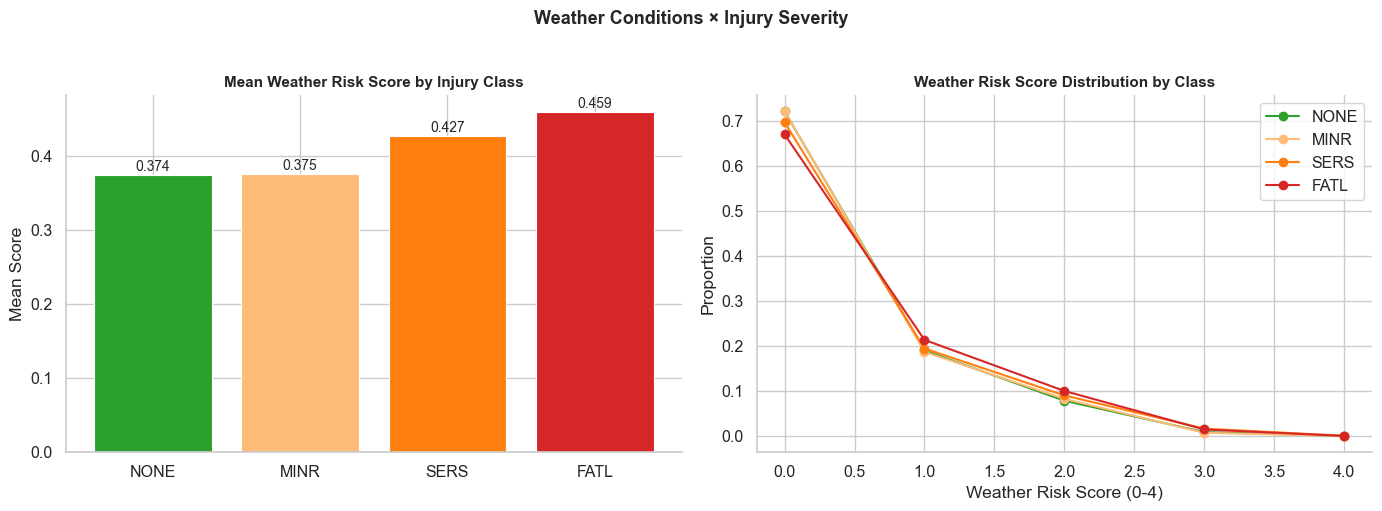

In [12]:
# Weather risk score composite vs target
weather_flags = ['noaa_fog', 'noaa_rain', 'noaa_snow', 'noaa_thunder']
weather_flags = [c for c in weather_flags if c in df.columns]

df['_weather_risk_score'] = df[weather_flags].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean weather risk score by class
order = ['NONE', 'MINR', 'SERS', 'FATL']
palette = {'NONE':'#2ca02c','MINR':'#ffbb78','SERS':'#ff7f0e','FATL':'#d62728'}
mean_risk = df.groupby('ev_highest_injury')['_weather_risk_score'].mean()[order]
axes[0].bar(order, mean_risk, color=[palette[c] for c in order],
            edgecolor='white', linewidth=0.8)
for i, v in enumerate(mean_risk):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
axes[0].set_title('Mean Weather Risk Score by Injury Class', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Score')
sns.despine(ax=axes[0])

# Distribution of weather risk score by class
for cls, col in palette.items():
    data = df[df['ev_highest_injury'] == cls]['_weather_risk_score']
    vc2 = data.value_counts(normalize=True).sort_index()
    axes[1].plot(vc2.index, vc2.values, marker='o', label=cls, color=col, linewidth=1.5)
axes[1].set_title('Weather Risk Score Distribution by Class', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Weather Risk Score (0-4)')
axes[1].set_ylabel('Proportion')
axes[1].legend()
sns.despine(ax=axes[1])

plt.suptitle('Weather Conditions × Injury Severity', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_multivariate_weather_severity.png', dpi=150, bbox_inches='tight')
plt.show()


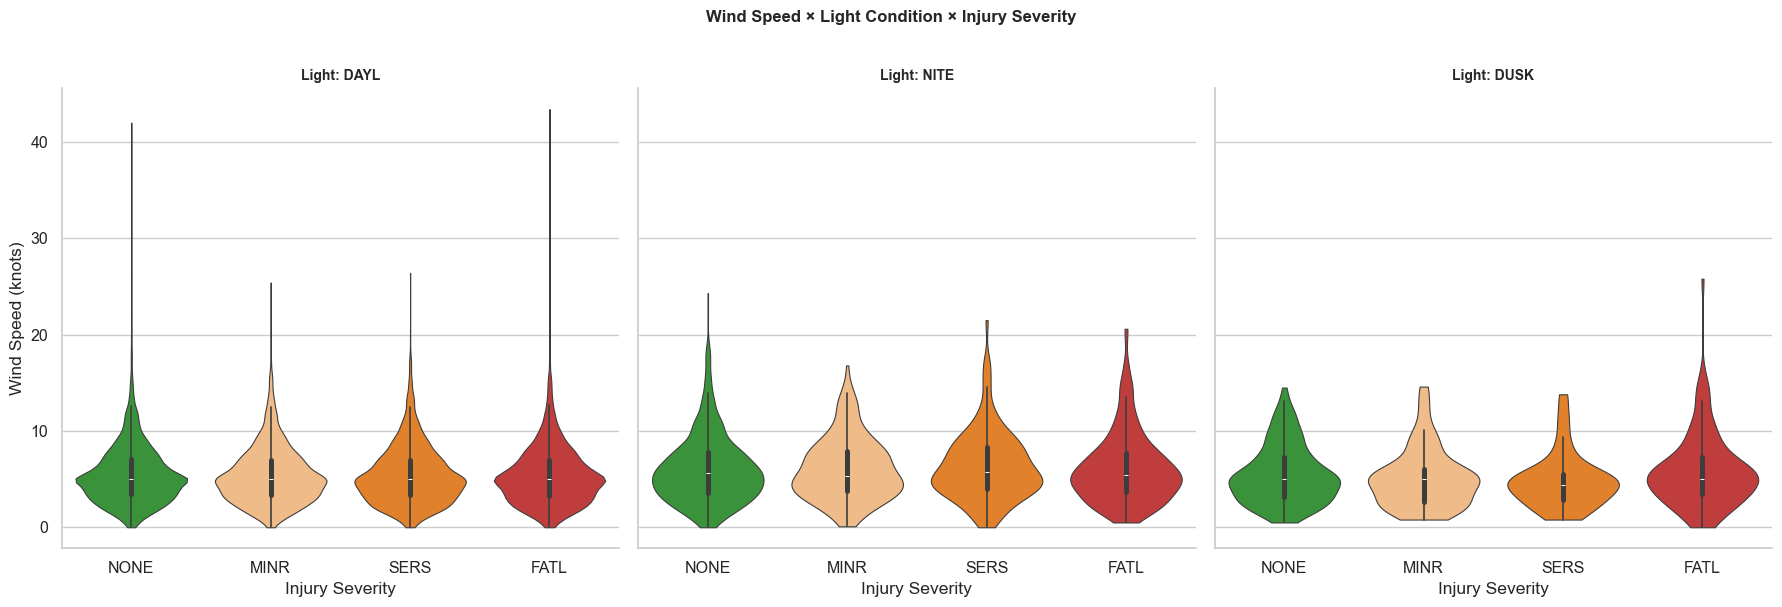

In [13]:
# Violin: wind speed × light condition × severity
if 'noaa_wind_knots' in df.columns and 'light_cond' in df.columns:
    top_light = df['light_cond'].value_counts().head(3).index.tolist()
    df_sub = df[df['light_cond'].isin(top_light)].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for ax, lc in zip(axes, top_light):
        subset = df_sub[df_sub['light_cond'] == lc]
        sns.violinplot(data=subset, x='ev_highest_injury', y='noaa_wind_knots',
                       order=['NONE','MINR','SERS','FATL'],
                       palette=palette, linewidth=0.8, cut=0, ax=ax)
        ax.set_title(f'Light: {lc}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Injury Severity')
        ax.set_ylabel('Wind Speed (knots)' if ax == axes[0] else '')
        sns.despine(ax=ax)

    plt.suptitle('Wind Speed × Light Condition × Injury Severity', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/09_multivariate_wind_light_severity.png', dpi=150, bbox_inches='tight')
    plt.show()


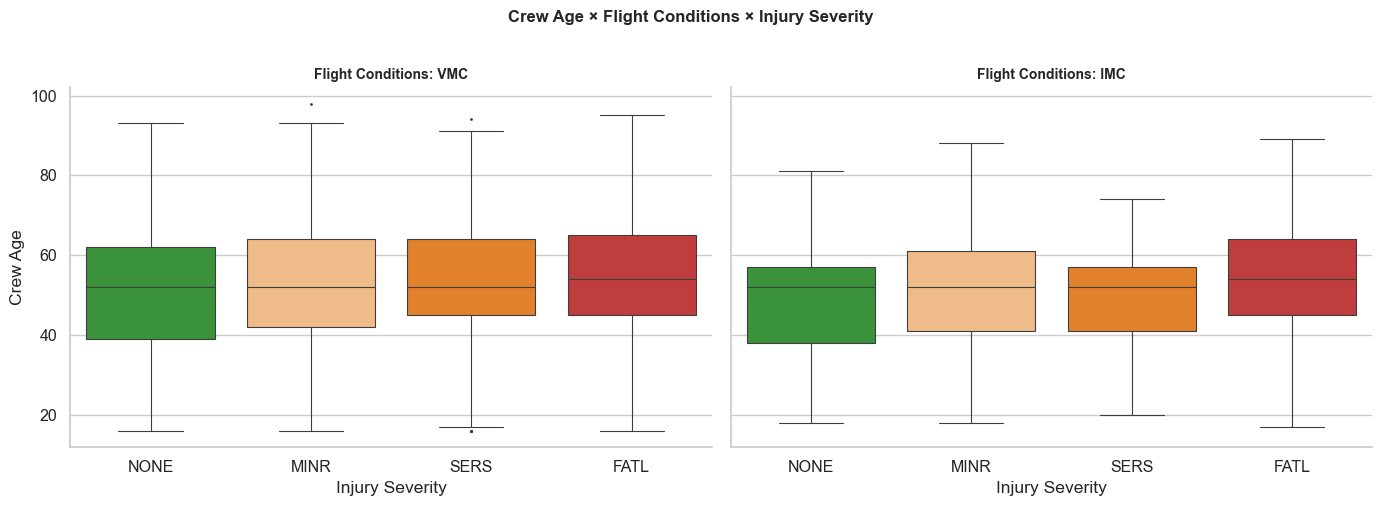

In [14]:
# Crew age × IMC vs VFR split
if 'crew_age' in df.columns and 'wx_cond_basic' in df.columns:
    df_imc = df[df['wx_cond_basic'].isin(['IMC','VMC'])].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, cond in zip(axes, ['VMC', 'IMC']):
        subset = df_imc[df_imc['wx_cond_basic'] == cond]
        sns.boxplot(data=subset, x='ev_highest_injury', y='crew_age',
                    order=['NONE','MINR','SERS','FATL'], palette=palette,
                    fliersize=1, linewidth=0.8, ax=ax)
        ax.set_title(f'Flight Conditions: {cond}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Injury Severity')
        ax.set_ylabel('Crew Age' if ax == axes[0] else '')
        sns.despine(ax=ax)

    plt.suptitle('Crew Age × Flight Conditions × Injury Severity', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/10_multivariate_age_cond_severity.png', dpi=150, bbox_inches='tight')
    plt.show()


## 8. Temporal Trends

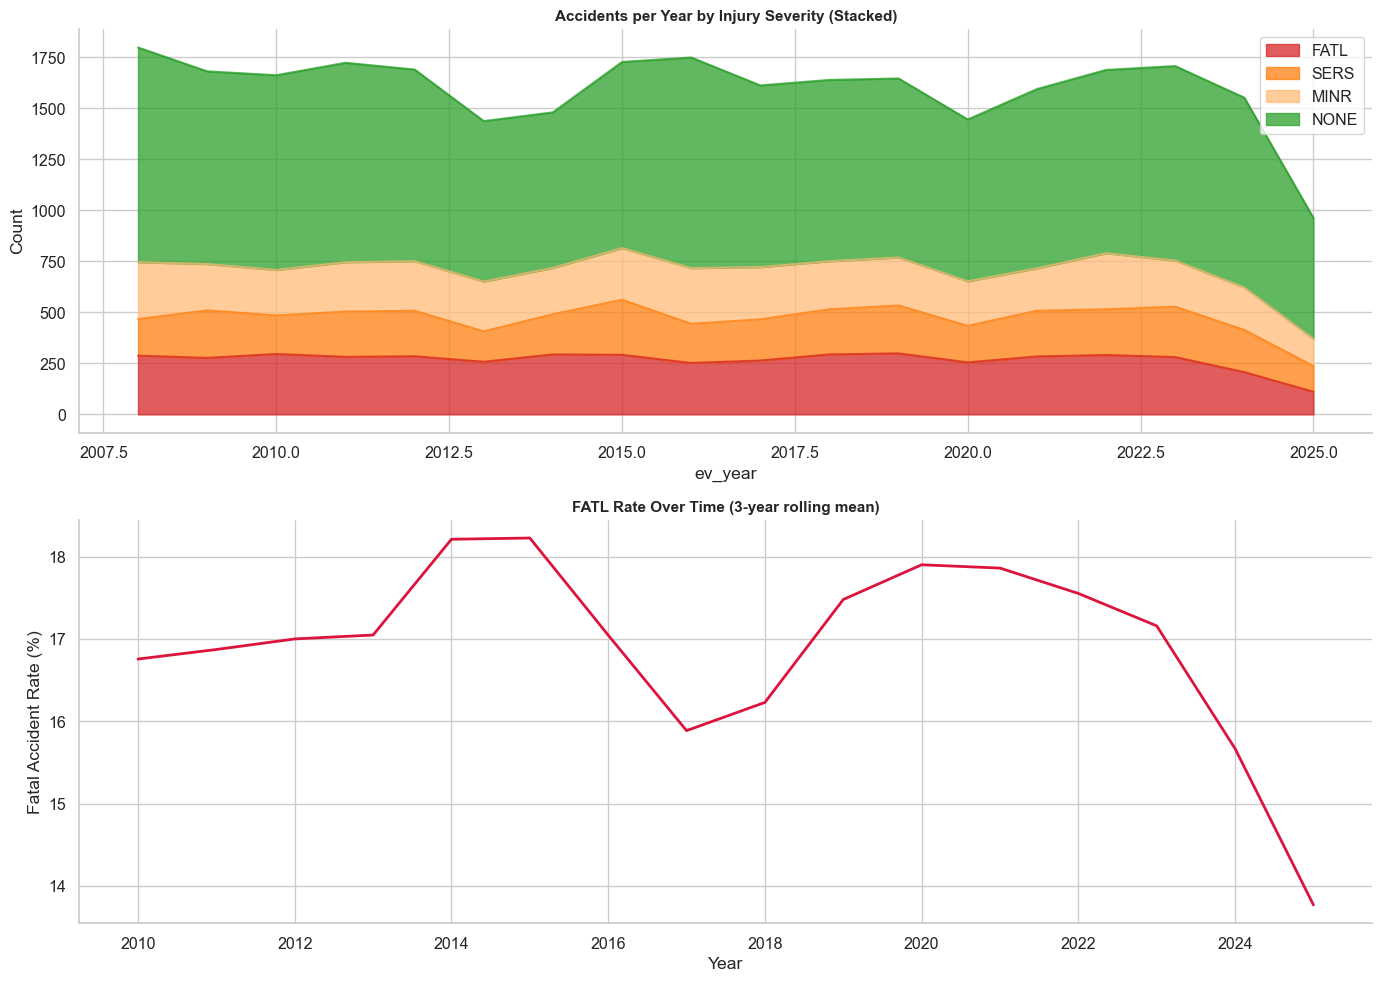

In [15]:
if 'ev_year' in df.columns:
    # Accidents per year by severity
    yearly = df.groupby(['ev_year', 'ev_highest_injury']).size().unstack(fill_value=0)
    yearly = yearly[[c for c in ['FATL','SERS','MINR','NONE'] if c in yearly.columns]]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Stacked area
    yearly.plot(kind='area', stacked=True, alpha=0.75, color=colors_stack[::-1], ax=axes[0])
    axes[0].set_title('Accidents per Year by Injury Severity (Stacked)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].legend(loc='upper right')
    sns.despine(ax=axes[0])

    # Fatal rate over time
    fatl_rate = (yearly['FATL'] / yearly.sum(axis=1) * 100).rolling(3).mean()
    fatl_rate.plot(ax=axes[1], color='crimson', linewidth=2)
    axes[1].set_title('FATL Rate Over Time (3-year rolling mean)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Fatal Accident Rate (%)')
    axes[1].set_xlabel('Year')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/11_temporal_trends.png', dpi=150, bbox_inches='tight')
    plt.show()


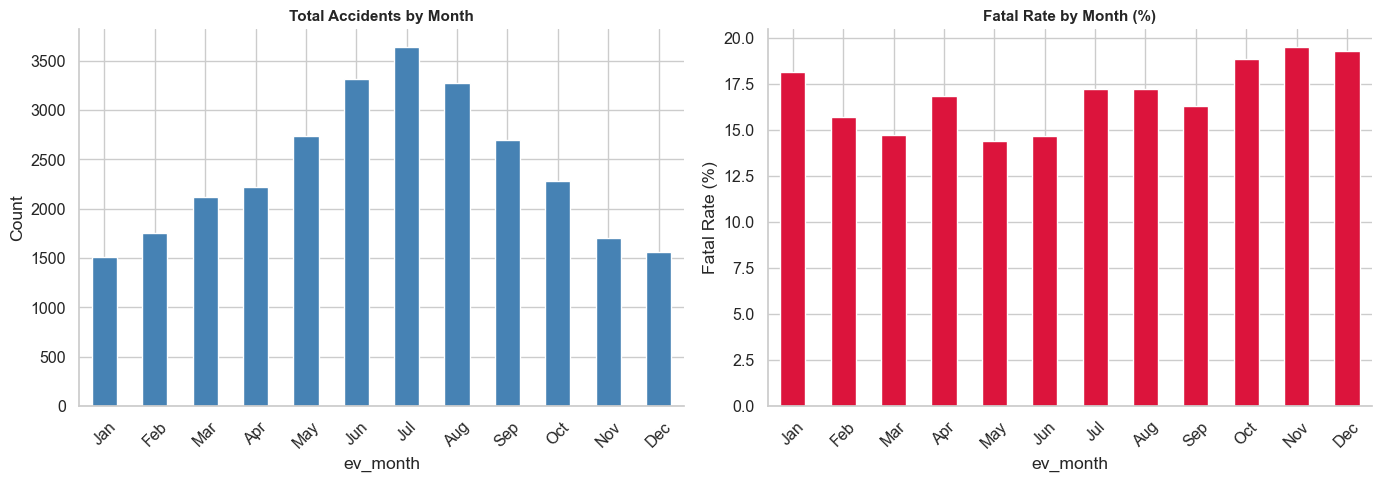

In [16]:
if 'ev_month' in df.columns:
    # Monthly seasonality
    monthly_fatl = df[df['ev_highest_injury']=='FATL'].groupby('ev_month').size()
    monthly_total = df.groupby('ev_month').size()
    monthly_rate = (monthly_fatl / monthly_total * 100).fillna(0)

    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    monthly_total.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_xticklabels(month_names, rotation=45)
    axes[0].set_title('Total Accidents by Month', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count')
    sns.despine(ax=axes[0])

    monthly_rate.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
    axes[1].set_xticklabels(month_names, rotation=45)
    axes[1].set_title('Fatal Rate by Month (%)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Fatal Rate (%)')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/12_monthly_patterns.png', dpi=150, bbox_inches='tight')
    plt.show()


## 9. Geographic Distribution

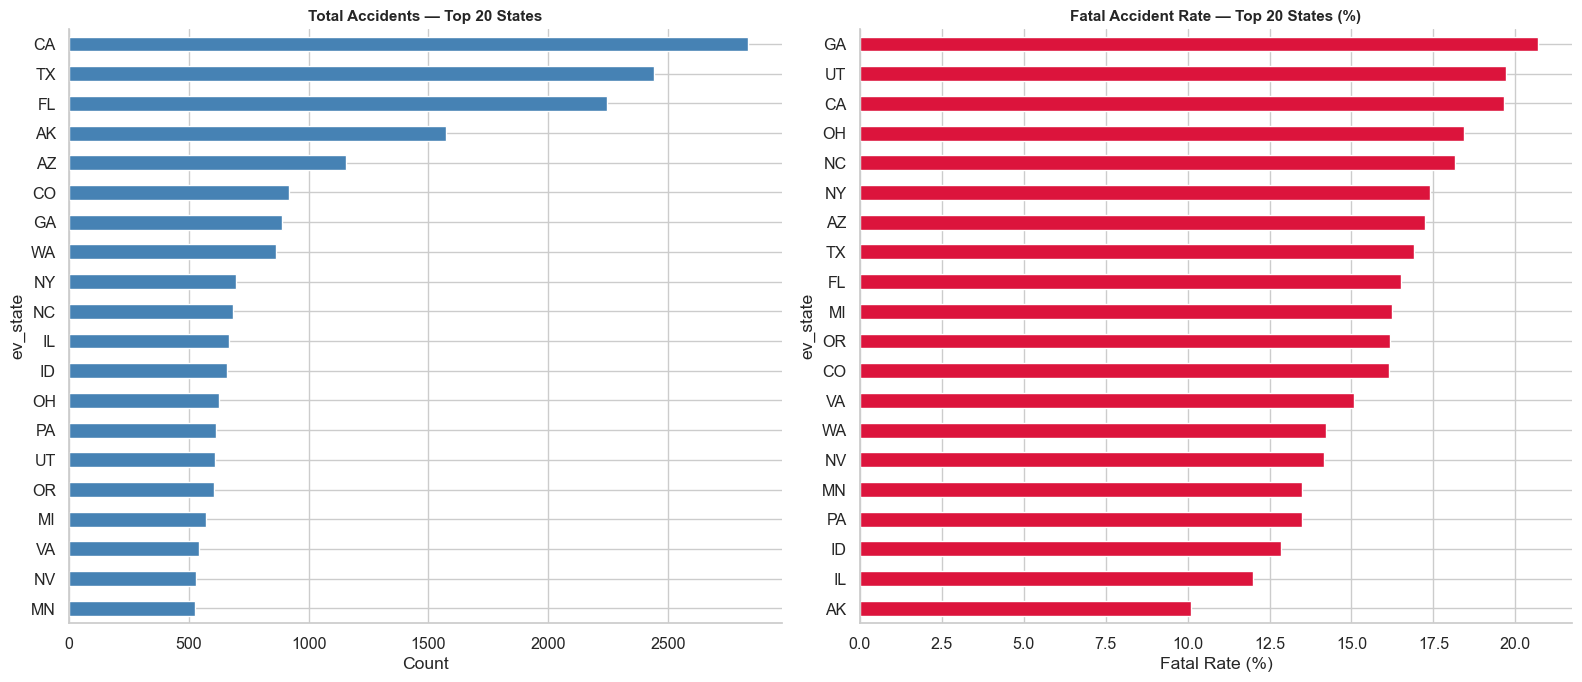

In [17]:
if 'ev_state' in df.columns:
    # Top 20 states by accident count
    state_counts = df.groupby('ev_state').size().sort_values(ascending=False).head(20)
    state_fatl   = df[df['ev_highest_injury']=='FATL'].groupby('ev_state').size()
    state_rate   = (state_fatl / df.groupby('ev_state').size() * 100).fillna(0)
    state_rate_top20 = state_rate[state_counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    state_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Total Accidents — Top 20 States', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Count')
    sns.despine(ax=axes[0])

    state_rate_top20.sort_values().plot(kind='barh', ax=axes[1], color='crimson', edgecolor='white')
    axes[1].set_title('Fatal Accident Rate — Top 20 States (%)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Fatal Rate (%)')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/13_geographic_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


## 10. Key Findings Summary

In [18]:
print("=" * 65)
print("  EDA KEY FINDINGS")
print("=" * 65)

vc = df['ev_highest_injury'].value_counts()
print(f"\nDataset size        : {len(df):,} accidents")
print(f"Target classes      : {list(vc.index)}")
print(f"Imbalance NONE/FATL : {vc.get('NONE',0)/vc.get('FATL',1):.1f}x")

if 'noaa_wind_knots' in df.columns:
    mean_wind_fatl = df[df['ev_highest_injury']=='FATL']['noaa_wind_knots'].mean()
    mean_wind_none = df[df['ev_highest_injury']=='NONE']['noaa_wind_knots'].mean()
    print(f"\nMean wind (FATL)    : {mean_wind_fatl:.1f} kts")
    print(f"Mean wind (NONE)    : {mean_wind_none:.1f} kts")

if 'crew_age' in df.columns:
    mean_age_fatl = df[df['ev_highest_injury']=='FATL']['crew_age'].mean()
    mean_age_none = df[df['ev_highest_injury']=='NONE']['crew_age'].mean()
    print(f"\nMean crew age (FATL): {mean_age_fatl:.1f} yr")
    print(f"Mean crew age (NONE): {mean_age_none:.1f} yr")

if 'ev_year' in df.columns:
    print(f"\nDate range          : {int(df['ev_year'].min())} – {int(df['ev_year'].max())}")

# Clean up temp column
if '_weather_risk_score' in df.columns:
    df.drop(columns=['_weather_risk_score'], inplace=True)

print(f"\nEDA plots saved to  : {OUTPUT_DIR}/")


  EDA KEY FINDINGS

Dataset size        : 28,810 accidents
Target classes      : ['NONE', 'FATL', 'MINR', 'SERS']
Imbalance NONE/FATL : 3.3x

Mean wind (FATL)    : 5.6 kts
Mean wind (NONE)    : 5.5 kts

Mean crew age (FATL): 53.7 yr
Mean crew age (NONE): 50.3 yr

Date range          : 2008 – 2025

EDA plots saved to  : outputs/eda/
